In [43]:
!pip install kaggle

In [44]:
# Cell 2 - Upload the kaggle.json file
from google.colab import files
uploaded = files.upload()   # Select your kaggle.json file here

# Cell 3 - Set it up
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Cell 4 - Download Face Mask Dataset
!kaggle datasets download -d omkargurav/face-mask-dataset

# Cell 5 - Unzip
!unzip face-mask-dataset.zip -d face-mask-dataset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  face-mask-dataset.zip
replace face-mask-dataset/data/with_mask/with_mask_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [45]:
!ls

drive		   face-mask-dataset.zip     sample_data
face-mask-dataset  face_mask_detector.keras


**Importing the Dependencies**


In [46]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

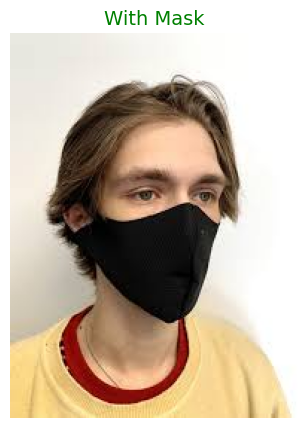

In [47]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

with_mask_path = '/content/face-mask-dataset/data/with_mask/'
with_mask_files = os.listdir(with_mask_path)

# Display only 1 image
img = mpimg.imread(with_mask_path + with_mask_files[0])

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title('With Mask', color='green', fontsize=14)
plt.axis('off')
plt.show()

In [48]:
with_mask_file = os.listdir('/content/face-mask-dataset/data/with_mask')
print(with_mask_file[0:10])
print(with_mask_file[-5:])

['with_mask_2410.jpg', 'with_mask_1790.jpg', 'with_mask_1192.jpg', 'with_mask_2958.jpg', 'with_mask_3702.jpg', 'with_mask_3430.jpg', 'with_mask_164.jpg', 'with_mask_3100.jpg', 'with_mask_3487.jpg', 'with_mask_1587.jpg']
['with_mask_2120.jpg', 'with_mask_1292.jpg', 'with_mask_2108.jpg', 'with_mask_1676.jpg', 'with_mask_1420.jpg']


In [49]:
print('Number of with mask images:', len(with_mask_file))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


Creating Labels for the two class of images


1.   with mask--->1
2.   withoutmask-->0



In [50]:
#create the labels
with_mask_labels = [1]*3725
without_mask_labels = [0]*3825

In [51]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])


[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [52]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3825


In [53]:
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7550
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the images**

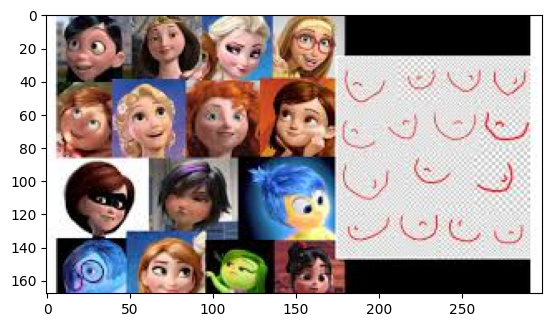

In [54]:
#displaying with mask image
img = mpimg.imread('/content/face-mask-dataset/data/without_mask/without_mask_2960.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**


1.  Resize the images
2.  Convert the images to arrays



In [55]:
data = []    # Initialize ONCE
labels = []  # For storing 1 = mask, 0 = no mask
# With mask images → label 1
for img_file in with_mask_files:
    image = Image.open(with_mask_path + img_file)
    image = image.resize((128, 128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)
    labels.append(1)
# Without mask images → label 0
for img_file in without_mask_files:
    image = Image.open(without_mask_path + img_file)
    image = image.resize((128, 128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)
    labels.append(0)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [56]:
type(data)

list

In [57]:
len(data)

7553

array([[[233, 233, 225],
        [233, 233, 225],
        [233, 233, 225],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[233, 233, 225],
        [233, 233, 225],
        [233, 233, 225],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[233, 233, 225],
        [233, 233, 225],
        [233, 233, 225],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[249, 212, 131],
        [249, 213, 130],
        [249, 213, 128],
        ...,
        [252, 255, 249],
        [252, 255, 253],
        [255, 255, 255]],

       [[249, 212, 131],
        [248, 211, 130],
        [248, 212, 128],
        ...,
        [254, 255, 247],
        [253, 255, 254],
        [255, 255, 255]],

       [[248, 211, 131],
        [248, 211, 130],
        [247, 211, 128],
        ...,
        [254, 255, 244],
        [253, 255, 254],
        [255, 255, 255]]], dtype=uint8)
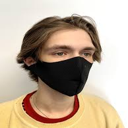

In [58]:
data[0]

In [59]:
type(data[0])

numpy.ndarray

In [60]:
data[0].shape

(128, 128, 3)

In [61]:
#converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [62]:
type(X)
type(Y)

numpy.ndarray

In [63]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


**Train Test split**

In [64]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [65]:
#scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255

**Builing a convolutional Neural Network(CNN)**

In [66]:
import keras
from keras.callbacks import EarlyStopping

#CNN model
model = keras.Sequential()

model.add(keras.Input(shape=(128, 128, 3)))

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(2, activation='softmax'))

#Compiling the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',
                            patience=5,
                            restore_best_weights=True)

#Train
#scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255
history = model.fit(X_train_scaled, Y_train,
                    validation_split=0.1,
                    epochs=20,
                    callbacks=[early_stop])

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.7177 - loss: 0.7090 - val_accuracy: 0.8595 - val_loss: 0.3242
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8825 - loss: 0.3025 - val_accuracy: 0.8760 - val_loss: 0.2919
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9105 - loss: 0.2299 - val_accuracy: 0.8760 - val_loss: 0.3329
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9256 - loss: 0.1934 - val_accuracy: 0.9107 - val_loss: 0.2234
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9342 - loss: 0.1680 - val_accuracy: 0.9091 - val_loss: 0.2424
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9526 - loss: 0.1281 - val_accuracy: 0.8975 - val_loss: 0.2540
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9519 - loss: 0.1198 - val_accuracy: 0.9107 - val_loss: 0.2406
Epoch 8/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9612 - loss: 0.1062 - val_acc

In [67]:
#Evaluating the model on test data
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Predicting on test data
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)  # convert probabilities → class

# Classification Report
from sklearn.metrics import classification_report
print(classification_report(Y_test, y_pred_classes,
      target_names=['Without Mask', 'With Mask']))

#Save the model
model.save('face_mask_detector.keras')
print("Model saved in Keras format!")

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9304 - loss: 0.1648
Test Accuracy: 92.59%
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
              precision    recall  f1-score   support

Without Mask       0.93      0.92      0.93       768
   With Mask       0.92      0.93      0.93       743

    accuracy                           0.93      1511
   macro avg       0.93      0.93      0.93      1511
weighted avg       0.93      0.93      0.93      1511

Model saved in Keras format!
